В этом ноутбуке содержатся основные этапы разработки системы автоматической классификации злокачественных и доброкачественных новообразований кожи на основе сверточных нейронных сетей. Ссылка на датасет:
https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000

Получение данных:

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


Изменение размера изображений:

In [ ]:
import os
import cv2

def preprocess_dataset_simple(source_dir, target_dir, target_folders, target_size=(224, 224)):
    os.makedirs(target_dir, exist_ok=True)
    path_mapping = {}
    counter = 0
    for folder in target_folders:
        current_source_folder = os.path.join(source_dir, folder)
        if not os.path.exists(current_source_folder):
            print(f"Предупреждение: Папка {current_source_folder} не найдена!")
            continue

        for file in os.listdir(current_source_folder):
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                old_path = os.path.join(current_source_folder, file)
                new_path = os.path.join(target_dir, file)
                img = cv2.imread(old_path)
                if img is None:
                    print(f"Пропущен битый файл: {old_path}")
                    continue

                img_resized = cv2.resize(img, target_size)
                cv2.imwrite(new_path, img_resized, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
                filename_without_ext, _ = os.path.splitext(file)
                path_mapping[filename_without_ext] = new_path
                counter += 1
                if counter % 500 == 0:
                    print(f"Обработано картинок: {counter}")

    print(f"Успешно обработано всего картинок: {counter}")
    return path_mapping

In [ ]:
from pathlib import Path

result_path = Path("/kaggle/working/resized")
result_path.mkdir(parents=True, exist_ok=False)

TARGET_SIZE = (224, 224)
subfolders = ["HAM10000_images_part_1", "HAM10000_images_part_2"]
imageid_path_dict = preprocess_dataset_simple(path, result_path, subfolders, TARGET_SIZE)

Обработано картинок: 500
Обработано картинок: 1000
Обработано картинок: 1500
Обработано картинок: 2000
Обработано картинок: 2500
Обработано картинок: 3000
Обработано картинок: 3500
Обработано картинок: 4000
Обработано картинок: 4500
Обработано картинок: 5000
Обработано картинок: 5500
Обработано картинок: 6000
Обработано картинок: 6500
Обработано картинок: 7000
Обработано картинок: 7500
Обработано картинок: 8000
Обработано картинок: 8500
Обработано картинок: 9000
Обработано картинок: 9500
Обработано картинок: 10000
Успешно обработано всего картинок: 10015


Наименования видов поражения:

In [ ]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

Таблица признаков и путей к файлам:

In [ ]:
import pandas as pd

skin_df = pd.read_csv(os.path.join(path, 'HAM10000_metadata.csv'))
skin_df['path'] = skin_df['image_id'].map(imageid_path_dict.get)
skin_df['cell_type'] = skin_df['dx'].map(lesion_type_dict.get)
skin_df['cell_type_idx'] = pd.Categorical(skin_df['cell_type']).codes
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/working/resized/ISIC_0027419.jpg,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/working/resized/ISIC_0025030.jpg,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/working/resized/ISIC_0026769.jpg,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/working/resized/ISIC_0025661.jpg,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/working/resized/ISIC_0031633.jpg,Benign keratosis-like lesions,2


Индексы видов поражения:

In [ ]:
leison_type_index_mapping = dict(enumerate(pd.Categorical(skin_df['cell_type']).categories))
leison_type_index_mapping

{0: 'Actinic keratoses',
 1: 'Basal cell carcinoma',
 2: 'Benign keratosis-like lesions',
 3: 'Dermatofibroma',
 4: 'Melanocytic nevi',
 5: 'Melanoma',
 6: 'Vascular lesions'}

Разведывательный анализ данных:

<Axes: xlabel='cell_type'>

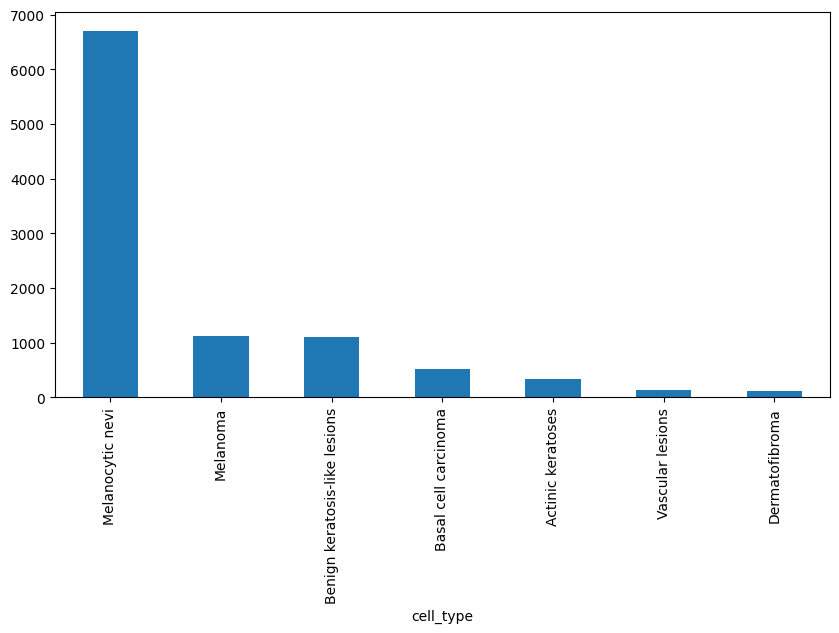

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(1, 1, figsize= (10, 5))
skin_df['cell_type'].value_counts().plot(kind='bar', ax=ax1)

<Axes: ylabel='count'>

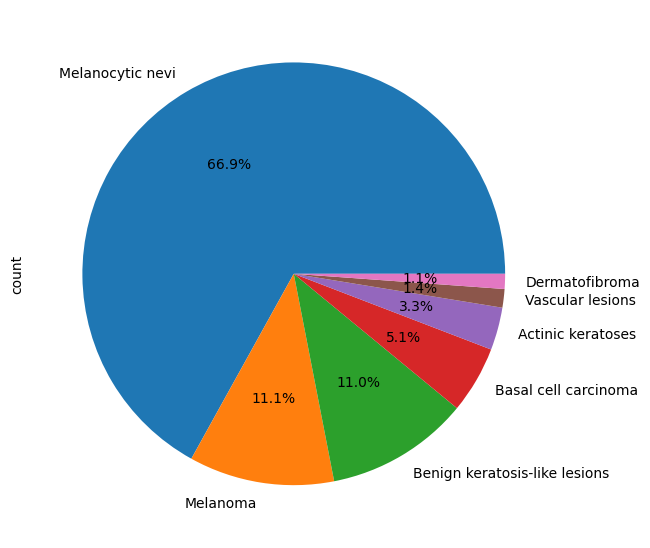

In [ ]:
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
skin_df['cell_type_idx'].value_counts().rename(index=leison_type_index_mapping).plot.pie(autopct="%1.1f%%")

<small>Из гистограммы следует, что в датасете преобладают обычные родинки (melanocytic nevi, 66,9%). Доля остальных 6 классов, в том числе опасных меланом и базальноклеточных карцином невелика (11,1 и 5,1%). Таким образом, для многоклассовой классификации в задаче классификации видов поражения кожи важно корректно определять те именно классы, которые представлены в датасете в небольшом количестве.<small/>

<Axes: xlabel='localization'>

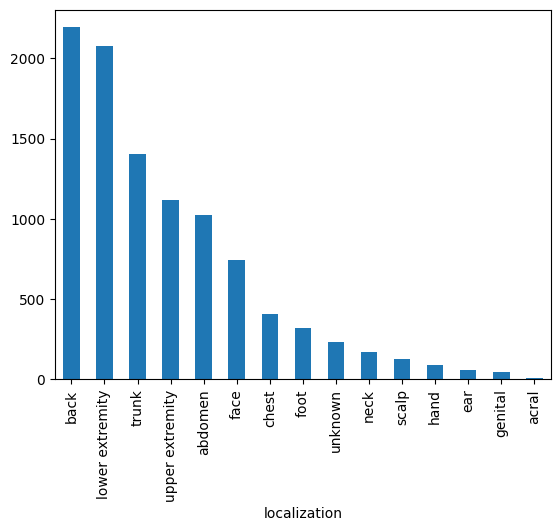

In [ ]:
skin_df['localization'].value_counts().plot(kind='bar')

<small>В данном исследовании принято решение рассматривать только изображения поражений кожи, не используя дополнительные признаки. Тем не менее, с целью описания исходного датасета ниже представлены некоторые его характеристики. Так, из гистограммы выше видно, что преобладающее расположение родинок - спина, нижние конечности, туловище, верхние конечности, живот, лицо.<small/>

<Axes: >

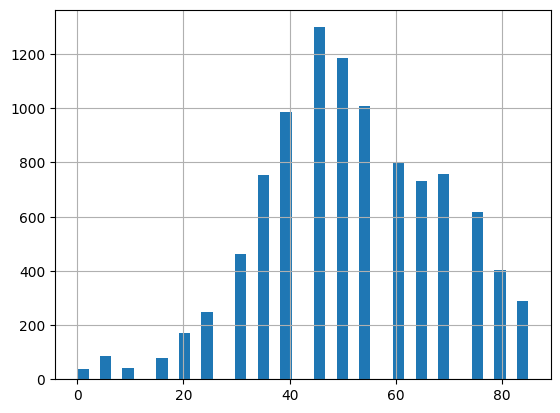

In [ ]:
skin_df['age'].hist(bins=40)

<small>В датасете наиболее представлены люди возрастом 40-60 лет.<small/>

<Axes: xlabel='sex'>

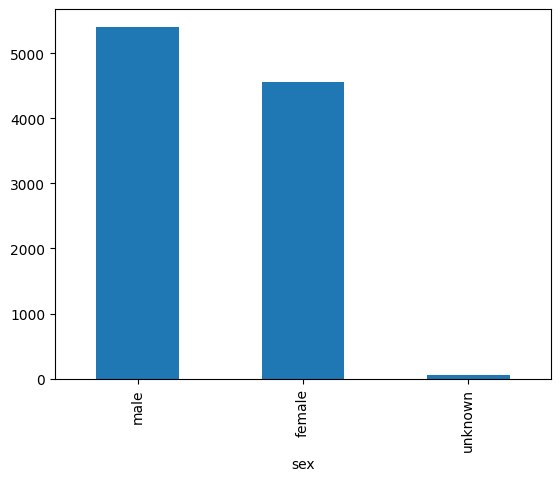

In [ ]:
skin_df['sex'].value_counts().plot(kind='bar')

<small>Женский и мужской пол в датасете представлены примерно поровну.<small/>

Ниже приведены некоторые примеры изображений различных классов из датасета:

In [ ]:
skin_df['image'] = skin_df['path'].map(lambda x: cv2.resize(cv2.cvtColor(cv2.imread(x), cv2.COLOR_BGR2RGB), (100, 75)))

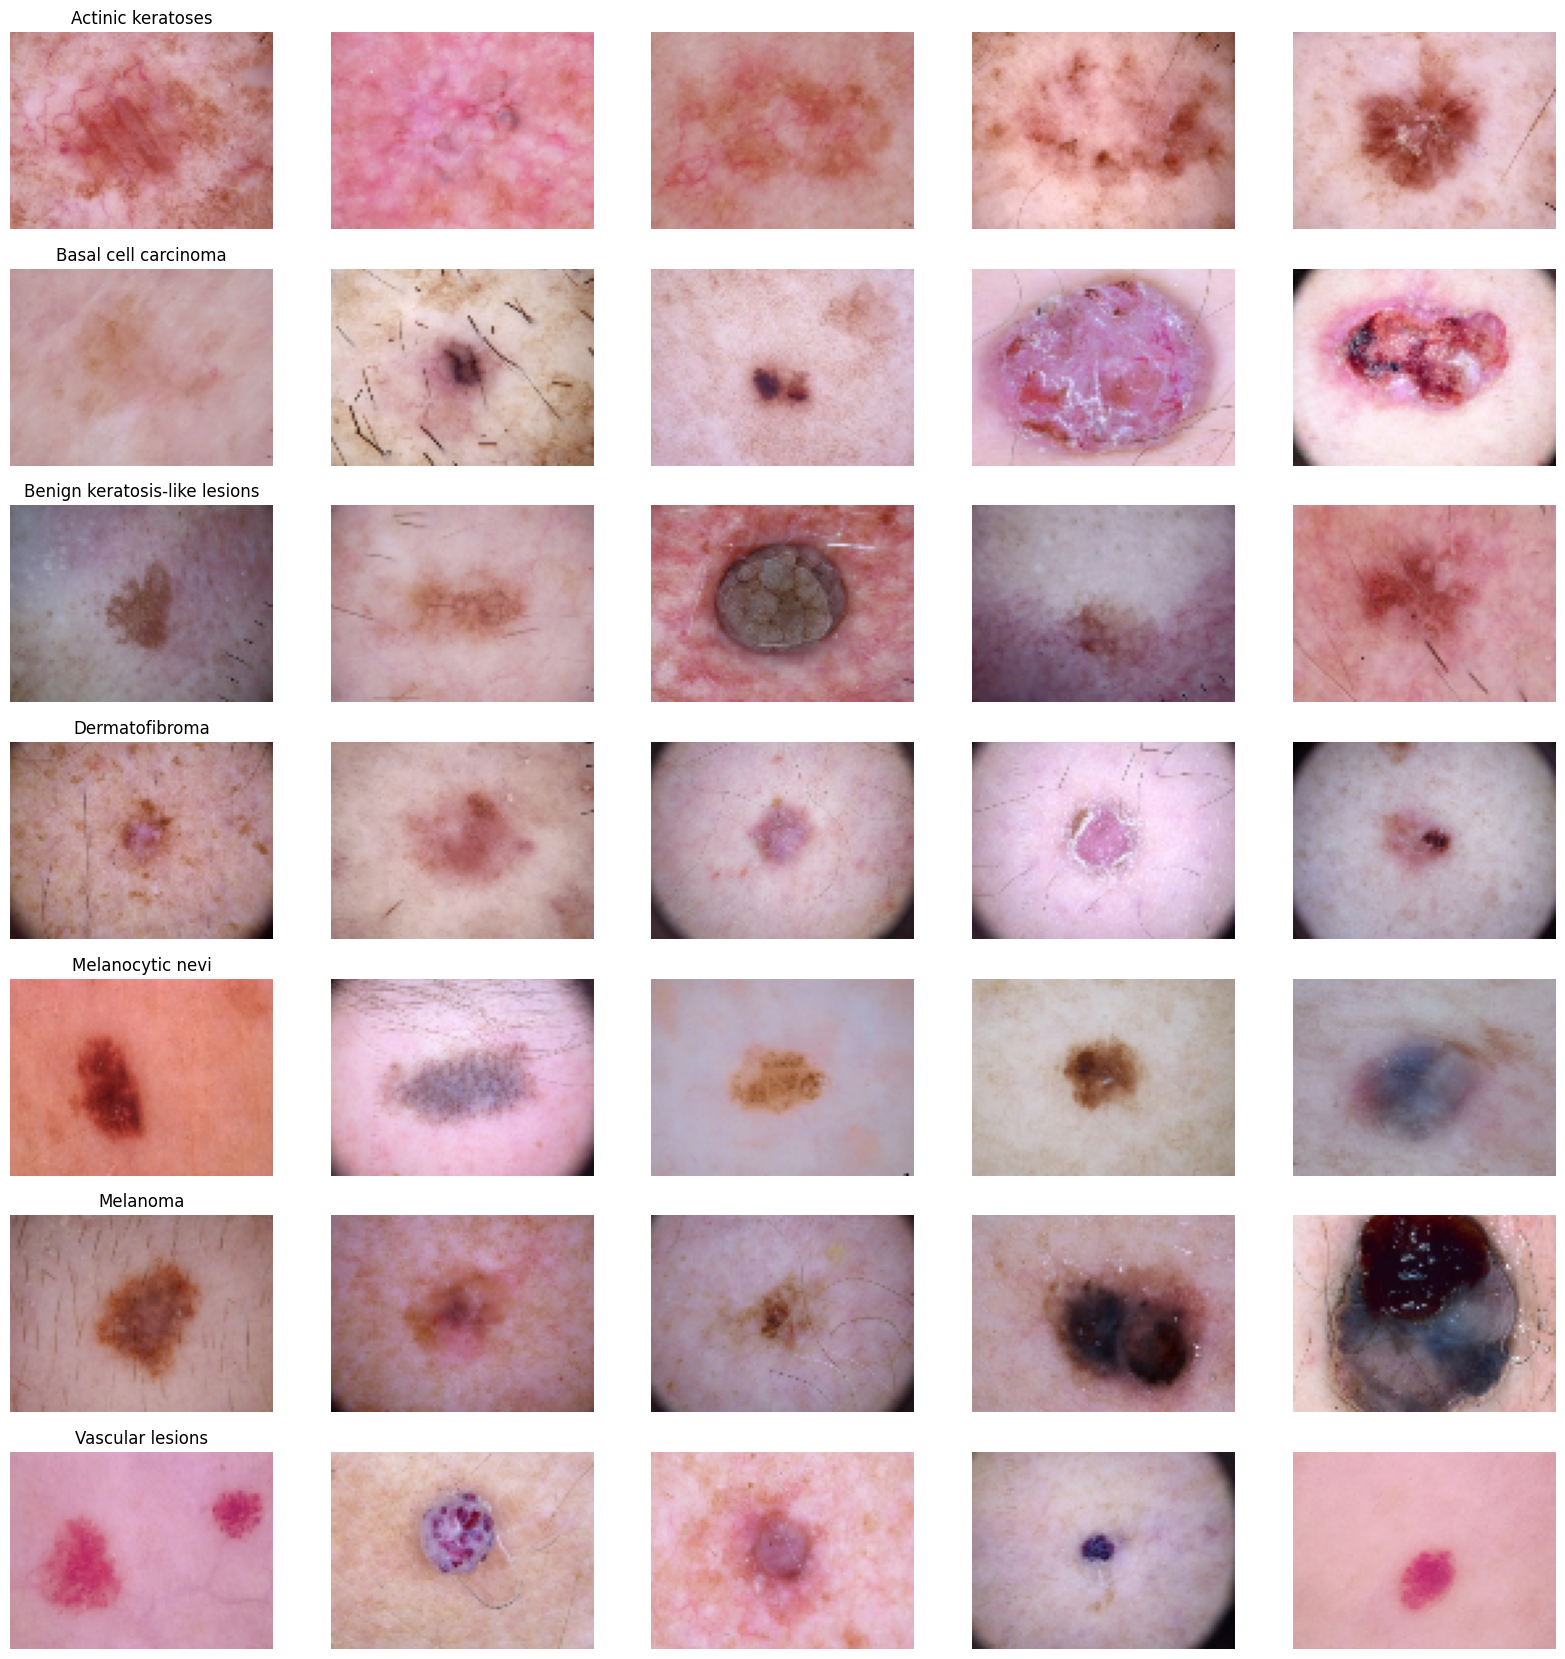

In [ ]:
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs,
                                         skin_df.sort_values(['cell_type']).groupby('cell_type')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=1234).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')
fig.savefig('category_samples.png', dpi=300)

Важно отметить, что в датасете одно поражение кожи может быть представлено несколькими фотографиями. Ниже выполнено разбиение на обучающую, валидационную и тестовую выборку так, чтобы одно и то же поражение не попадало в разные группы:

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss_test.split(skin_df, groups=skin_df['lesion_id']))

train_val_df = skin_df.iloc[train_val_idx].reset_index(drop=True)
test_df = skin_df.iloc[test_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['lesion_id']))

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print("Пересечение Train и Val:", len(set(train_df['lesion_id']).intersection(set(val_df['lesion_id']))) == 0)
print("Пересечение Train и Test:", len(set(train_df['lesion_id']).intersection(set(test_df['lesion_id']))) == 0)
print("Пересечение Val и Test:", len(set(val_df['lesion_id']).intersection(set(test_df['lesion_id']))) == 0)

Пересечение Train и Val: True
Пересечение Train и Test: True
Пересечение Val и Test: True


Создание генераторов:

In [ ]:
import numpy as np
import tensorflow as tf
from keras.utils import Sequence
from sklearn.model_selection import train_test_split

class ImageDatasetGenerator(Sequence):
    def __init__(self, file_paths, labels, batch_size=32, num_classes=None, shuffle=False):
        self.file_paths = np.array(file_paths)
        self.labels = tf.keras.utils.to_categorical(labels, num_classes=num_classes)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.file_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, idx):
        start = idx * self.batch_size
        end = min((idx + 1) * self.batch_size, len(self.file_paths))
        batch_indices = self.indices[start:end]

        batch_x = []
        for file_path in self.file_paths[batch_indices]:
            img = cv2.imread(file_path)

            if img is None:
                raise FileNotFoundError(f"Не удалось прочитать файл: {file_path}")

            img = img.astype(np.float32) / 255.0
            batch_x.append(img)

        batch_x = np.array(batch_x)
        batch_y = self.labels[batch_indices]

        return batch_x, batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
BATCH_SIZE = 32

train_generator = ImageDatasetGenerator(
    file_paths=train_df['path'].values,
    labels=train_df['cell_type_idx'].values, batch_size=BATCH_SIZE, shuffle=True
)

val_generator = ImageDatasetGenerator(
    file_paths=val_df['path'].values,
    labels=val_df['cell_type_idx'].values, batch_size=BATCH_SIZE, shuffle=False
)

test_generator = ImageDatasetGenerator(
    file_paths=test_df['path'].values,
    labels=test_df['cell_type_idx'].values, batch_size=BATCH_SIZE, shuffle=False
)

Метрики качества:

In [ ]:
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize=(7, 7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

def print_classification_report(y_true, y_pred, target_names):
  print(classification_report(y_true, np.argmax(y_pred, axis=1), target_names=target_names))

def print_results(model, test_generator, target_names):
    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(test_generator.labels, axis=1)
    confusion_mtx = confusion_matrix(y_true, y_pred_classes)
    plot_confusion_matrix(confusion_mtx, target_names)
    print_classification_report(y_true, y_pred, target_names)

Простая CNN-модель:

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, Activation, Input, GlobalAveragePooling2D
from keras import backend as K
import itertools
from keras.layers import BatchNormalization

from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split

import math

input_shape = TARGET_SIZE + (3,)
num_classes = 7

model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(GlobalAveragePooling2D())
model.add(Dropout(0.2))
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,951 (277.15 KB)

 Trainable params: 70,567 (275.65 KB)

 Non-trainable params: 384 (1.50 KB)

Коллбэки для уменьшения скорость обучения, когда прогресс замедляется, а также его остановки, когда метрика качества перестает расти:

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        verbose=1,
        min_lr=1e-6
    ),
    EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

Здесь и далее в моделях в качестве функции потерь используется CategoricalFocalCrossentropy, которая динамически уменьшает вклад легко классифицируемых (уверенных) примеров в общую ошибку, заставляя нейросеть фокусироваться на редких и сложных объектах:

In [ ]:
model.compile(optimizer=Adam(), loss=keras.losses.CategoricalFocalCrossentropy(), metrics=['f1_score', "accuracy"])

model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=callbacks,
    verbose = 1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 57s 177ms/step - accuracy: 0.6372 - f1_score: 0.1655 - loss: 0.1609 - val_accuracy: 0.6884 - val_f1_score: 0.1229 - val_loss: 0.1837 - learning_rate: 0.0010
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.6603 - f1_score: 0.1842 - loss: 0.1399 - val_accuracy: 0.6935 - val_f1_score: 0.2182 - val_loss: 0.1428 - learning_rate: 0.0010
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - accuracy: 0.6655 - f1_score: 0.2120 - loss: 0.1338 - val_accuracy: 0.6612 - val_f1_score: 0.2280 - val_loss: 0.1448 - learning_rate: 0.0010
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.6692 - f1_score: 0.2070 - loss: 0.1308 - val_accuracy: 0.6498 - val_f1_score: 0.2125 - val_loss: 0.1560 - learning_rate: 0.0010
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - accuracy: 0.6759 - f1_score: 0.2116 - loss: 0.1292 - val_accuracy: 0.6916 - val_f1_score: 0.1527 - val_loss: 0.1364 - learning_rate: 0.0010
Epoch 6/10

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step
                               precision    recall  f1-score   support

            Actinic keratoses       0.44      0.61      0.51        67
         Basal cell carcinoma       0.39      0.47      0.42        90
Benign keratosis-like lesions       0.63      0.37      0.47       243
               Dermatofibroma       0.50      0.06      0.10        18
             Melanocytic nevi       0.84      0.93      0.88      1336
                     Melanoma       0.50      0.35      0.41       236
             Vascular lesions       0.72      0.53      0.61        34

                     accuracy                           0.75      2024
                    macro avg       0.57      0.47      0.49      2024
                 weighted avg       0.74      0.75      0.73      2024



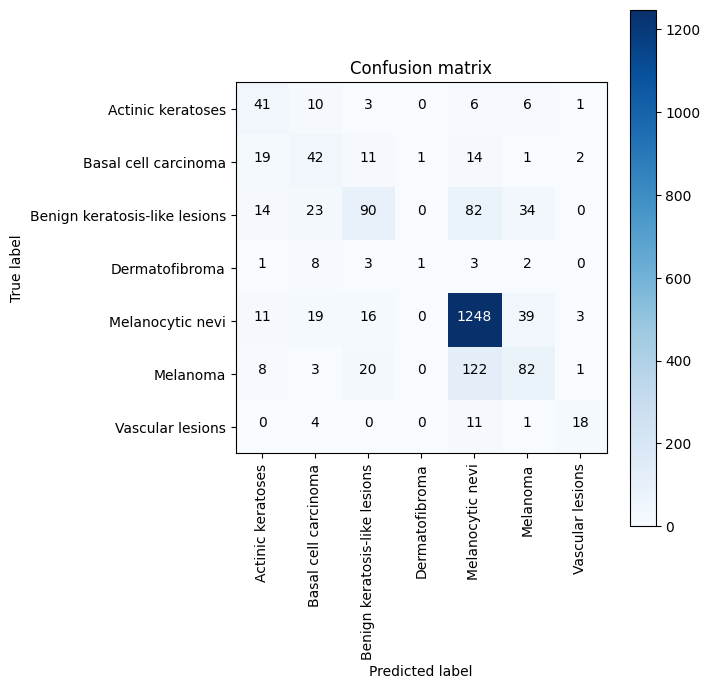

In [ ]:
print_results(model, test_generator, list(leison_type_index_mapping.values()))

<small> Из матрицы ошибок видно, что f1-score для простой модели из нескольких сверточных слоев равен 0,49. Обычные родинки классифицируются уверенно с f1 0,88. Опасные меланомы и базальноклеточные карциномы имеют f1 0,41 и 0,42.</small>

In [ ]:
model.save("simple_cnn_model.keras")

CNN-модель с аугментацией данных:

In [ ]:
from keras.layers import Activation, Input, RandomFlip, RandomRotation, RandomBrightness

model = Sequential()

model.add(Input(shape=input_shape))
model.add(RandomFlip("horizontal_and_vertical"))
model.add(RandomRotation(0.15))

model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(GlobalAveragePooling2D())
model.add(Dropout(0.2))
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           45

 Total params: 70,951 (277.15 KB)

 Trainable params: 70,567 (275.65 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss=keras.losses.CategoricalFocalCrossentropy(), metrics=['f1_score', "accuracy"])

model.fit(
    train_generator,
    validation_data=val_generator,
    batch_size=32,
    epochs=100,
    callbacks=callbacks,
    verbose = 1
)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 67s 294ms/step - accuracy: 0.6613 - f1_score: 0.1695 - loss: 0.1477 - val_accuracy: 0.6954 - val_f1_score: 0.1600 - val_loss: 0.1319 - learning_rate: 1.0000e-04
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 58s 289ms/step - accuracy: 0.6574 - f1_score: 0.1654 - loss: 0.1440 - val_accuracy: 0.6998 - val_f1_score: 0.1517 - val_loss: 0.1243 - learning_rate: 1.0000e-04
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 58s 289ms/step - accuracy: 0.6673 - f1_score: 0.1884 - loss: 0.1380 - val_accuracy: 0.7049 - val_f1_score: 0.2270 - val_loss: 0.1240 - learning_rate: 1.0000e-04
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 58s 290ms/step - accuracy: 0.6653 - f1_score: 0.1803 - loss: 0.1365 - val_accuracy: 0.7030 - val_f1_score: 0.1628 - val_loss: 0.1217 - learning_rate: 1.0000e-04
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 58s 289ms/step - accuracy: 0.6680 - f1_score: 0.1970 - loss: 0.1350 - val_accuracy: 0.7023 - val_f1_score: 0.2455 - val_loss: 0.1335 - learning_rate: 1

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                               precision    recall  f1-score   support

            Actinic keratoses       0.47      0.43      0.45        67
         Basal cell carcinoma       0.37      0.31      0.34        90
Benign keratosis-like lesions       0.52      0.38      0.44       243
               Dermatofibroma       0.00      0.00      0.00        18
             Melanocytic nevi       0.81      0.94      0.87      1336
                     Melanoma       0.49      0.33      0.40       236
             Vascular lesions       0.50      0.06      0.11        34

                     accuracy                           0.73      2024
                    macro avg       0.45      0.35      0.37      2024
                 weighted avg       0.70      0.73      0.70      2024



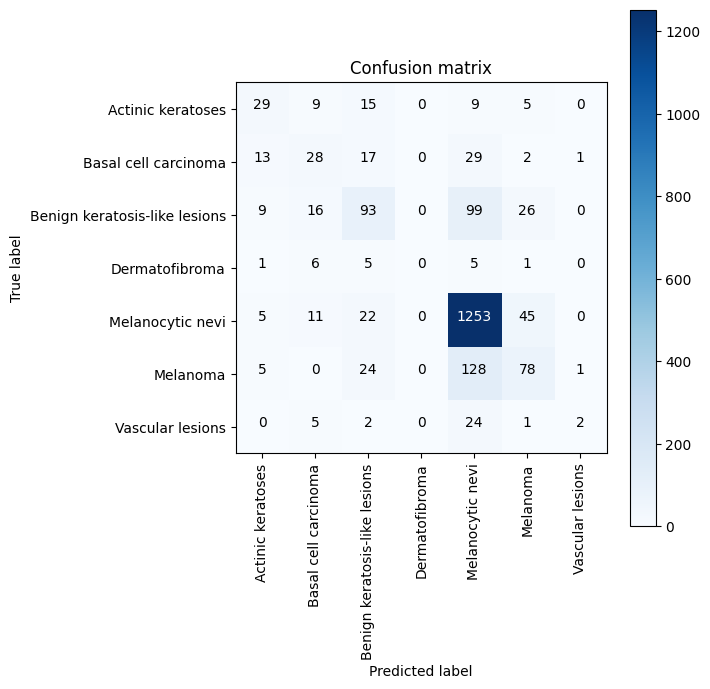

In [ ]:
print_results(model, test_generator, list(leison_type_index_mapping.values()))

<small> Оказалось, что для простой модели аугментация изображений не позволила улучшить качество. Наоборот, наблюдается даже небольшое снижение значений метрики f1 как для обычных родинок, так и для опасных классов. Изучение причин данного явления требует отдельного исследования и выходит за рамки данной работы.</small>

In [ ]:
model.save("augmentation_cnn_model.keras")

Модель CNN с переносом обучения:

In [ ]:
from keras.applications.resnet50 import ResNet50, preprocess_input
from keras.layers import GlobalAveragePooling2D, Lambda
from keras.applications.densenet import preprocess_input as dense_preprocess

model = Sequential()

model.add(Input(shape=input_shape))
model.add(RandomFlip("horizontal_and_vertical"))
model.add(RandomRotation(0.15))

model.add(Lambda(lambda x: preprocess_input(x * 255.0))),

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
base_model.trainable = False
model.add(base_model)

model.add(GlobalAveragePooling2D())
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,602,055 (90.03 MB)

 Trainable params: 14,343 (56.03 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss=keras.losses.CategoricalFocalCrossentropy(), metrics=['f1_score', "accuracy"])

model.fit(
    train_generator,
    validation_data=val_generator,
    batch_size=32,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


201/201 ━━━━━━━━━━━━━━━━━━━━ 50s 182ms/step - accuracy: 0.5834 - f1_score: 0.1749 - loss: 0.2241 - val_accuracy: 0.6802 - val_f1_score: 0.2093 - val_loss: 0.1483 - learning_rate: 1.0000e-04
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 164ms/step - accuracy: 0.6323 - f1_score: 0.2196 - loss: 0.1717 - val_accuracy: 0.7030 - val_f1_score: 0.2423 - val_loss: 0.1310 - learning_rate: 1.0000e-04
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 168ms/step - accuracy: 0.6581 - f1_score: 0.2677 - loss: 0.1497 - val_accuracy: 0.7144 - val_f1_score: 0.2775 - val_loss: 0.1216 - learning_rate: 1.0000e-04
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.6717 - f1_score: 0.3011 - loss: 0.1386 - val_accuracy: 0.7308 - val_f1_score: 0.2827 - val_loss: 0.1160 - learning_rate: 1.0000e-04
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 173ms/step - accuracy: 0.6876 - f1_score: 0.3356 - loss: 0.1284 - val_accuracy: 0.7403 - val_f1_score: 0.2992 - val_loss: 0.1114 - learning_rate: 1.0000e-04
Ep

64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 247ms/step
                               precision    recall  f1-score   support

            Actinic keratoses       0.56      0.36      0.44        67
         Basal cell carcinoma       0.50      0.49      0.49        90
Benign keratosis-like lesions       0.64      0.58      0.61       243
               Dermatofibroma       0.75      0.17      0.27        18
             Melanocytic nevi       0.87      0.92      0.89      1336
                     Melanoma       0.50      0.52      0.51       236
             Vascular lesions       0.86      0.35      0.50        34

                     accuracy                           0.78      2024
                    macro avg       0.67      0.48      0.53      2024
                 weighted avg       0.77      0.78      0.77      2024



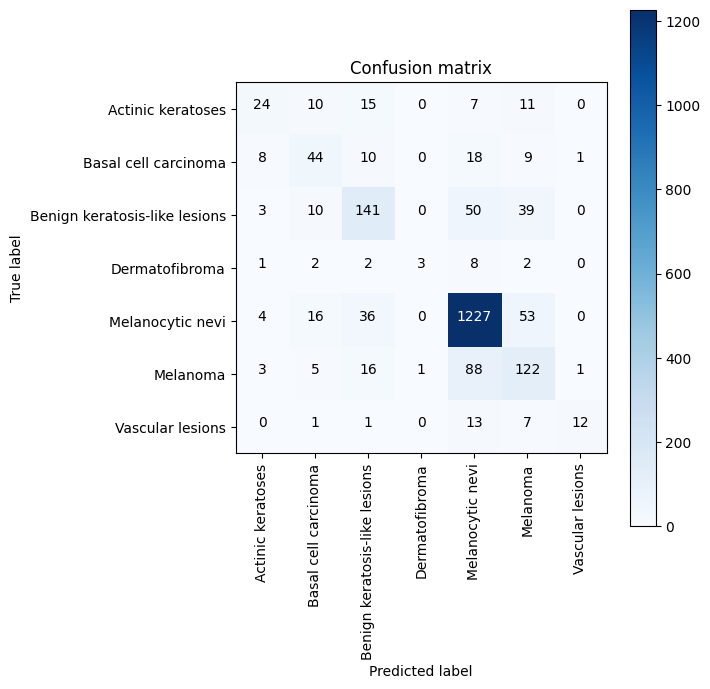

In [ ]:
print_results(model, test_generator, list(leison_type_index_mapping.values()))

In [ ]:
model.save("transfer_learning_cnn_model.keras")

<small> Для продолжения работы после ряда численных экспериментов с другими нейронными сетями было принято решение использовать перенос обучения из ResNet-50 - сверточной нейронной сети глубиной 50 слоев, созданной в 2015 году. На первом этапе обучался лишь собственный классификатор. Реализация данного подхода позволила существенно улучшить качество классификации для редких классов. В частности, f1 для опасных меланом и базальноклеточных карцином вырос до 0,51 и 0,49, а общий f1 увеличился до 0,53.</small>

Модель CNN с переносом обучения и fine-tuning:

In [ ]:
base_model.trainable = True

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss=keras.losses.CategoricalFocalCrossentropy(), metrics=['f1_score', "accuracy"])

In [ ]:
callbacks_fine_tuning = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

In [ ]:
model.fit(
    train_generator,
    validation_data=val_generator,
    batch_size=32,
    epochs=20,
    callbacks=callbacks_fine_tuning,
    verbose=1
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 159s 576ms/step - accuracy: 0.7522 - f1_score: 0.5453 - loss: 0.0925 - val_accuracy: 0.7574 - val_f1_score: 0.5076 - val_loss: 0.1258 - learning_rate: 1.0000e-04
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 115s 576ms/step - accuracy: 0.8196 - f1_score: 0.6991 - loss: 0.0578 - val_accuracy: 0.7524 - val_f1_score: 0.5373 - val_loss: 0.0877 - learning_rate: 1.0000e-04
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 117s 581ms/step - accuracy: 0.8478 - f1_score: 0.7653 - loss: 0.0453 - val_accuracy: 0.7701 - val_f1_score: 0.5627 - val_loss: 0.1137 - learning_rate: 1.0000e-04
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 117s 583ms/step - accuracy: 0.8662 - f1_score: 0.8048 - loss: 0.0378 - val_accuracy: 0.8005 - val_f1_score: 0.5764 - val_loss: 0.0790 - learning_rate: 1.0000e-04
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 117s 581ms/step - accuracy: 0.8780 - f1_score: 0.8127 - loss: 0.0339 - val_accuracy: 0.7872 - val_f1_score: 0.5864 - val_loss: 0.0806 - learning_rate: 1

64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 158ms/step
                               precision    recall  f1-score   support

            Actinic keratoses       0.95      0.30      0.45        67
         Basal cell carcinoma       0.67      0.68      0.67        90
Benign keratosis-like lesions       0.70      0.67      0.68       243
               Dermatofibroma       0.53      0.50      0.51        18
             Melanocytic nevi       0.87      0.95      0.91      1336
                     Melanoma       0.54      0.42      0.48       236
             Vascular lesions       0.89      0.74      0.81        34

                     accuracy                           0.81      2024
                    macro avg       0.74      0.61      0.65      2024
                 weighted avg       0.80      0.81      0.80      2024



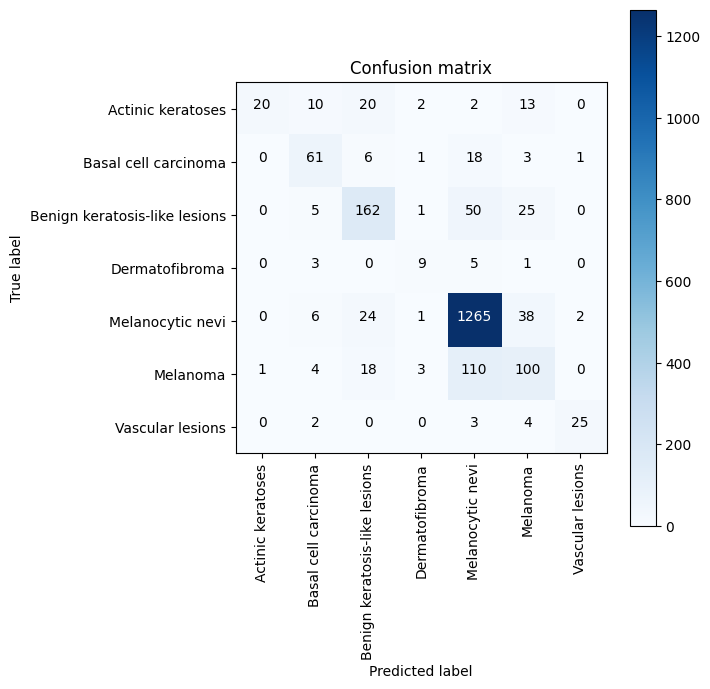

In [ ]:
print_results(model, test_generator, list(leison_type_index_mapping.values()))

<small> На втором этапе предпринята попытка полного дообучения. Размораживались все слои сети, но обучение шло с очень маленьким шагом. В результате отмечен резкий рост общего f1 до 0,65 в основном за счет улучшения классификации для  редких классов. Для опасных меланом f1 немного снизился и составил 0,49, для базальноклеточных карцином - значительно увеличился и достиг 0,67.</small>

In [ ]:
model.save("fine_tuning_cnn_model.keras")

Вывод: в ходе работы исследована возможность применения сверточных нейронных сетей для определения типов поражения кожи по изображению. Рассмотрена простая нейронная сеть, а также нейронная сеть на основе переноса обучения из ResNet-50. Лучшая модель на основе полного дообучения ResNet-50 показала средний f1 0.65, однако для опасной меланомы полнота осталась на уровне 0,42. Для базальноклеточной карциномы полнота равна 0,68. Таким образом, на данном этапе разработанная модель демонстрирует недостаточный уровень точности для решения медицинской задачи классификации поражений кожи, где критически важно корректное определение редких опасных классов. Однако рост точности от простых к более сложным моделям показывает глубокий потенциал нейронных сетей для решения подобных задач. Существуют возможности для повышения точности путем использования более сложных архитектур, например, трансформеров.